# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [11]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

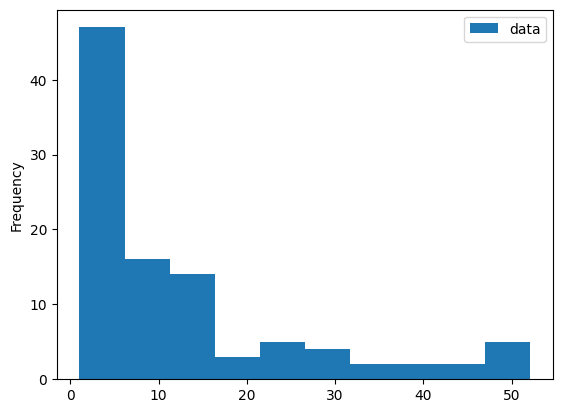

In [12]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

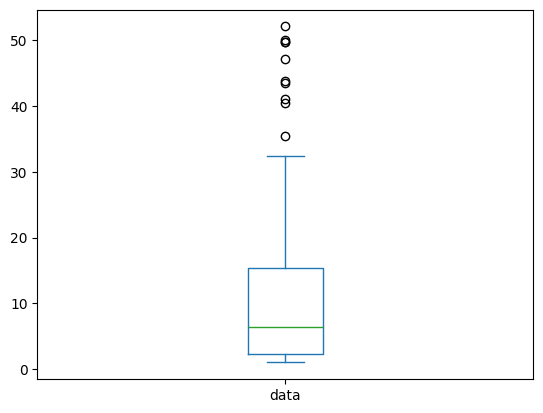

In [13]:
df.plot.box()

Both the histogram and the box plot show the same data but their stories are very different. The histograma does a good job of showing how the drug prices are spread out overall and whether the data is skewed or clustered in certain areas. The cons of using this graph is that it requires a little more effort to notice things like the median or extreme values. 

The box plot is more direct as we are able to quickly identify the median, spread, and any outliers instantly. Since the administrator wants to understand how comparable the more expensive drug is to the other drugs, I would choose the box plot since it makes the higher prices stick out noticeably. I would definitely change the data so it is more clear and maybe label the highest value so it could be more obvious. 

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [14]:
import pandas as pd
df = pd.read_csv("EdStatsData.csv (2).zip", compression='zip')
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df["Indicator Name"].unique()
literacy = df[df["Indicator Name"] == "Youth literacy rate, population 15-24 years, both sexes (%)"]
literacy_2015 = literacy["2015"].dropna()

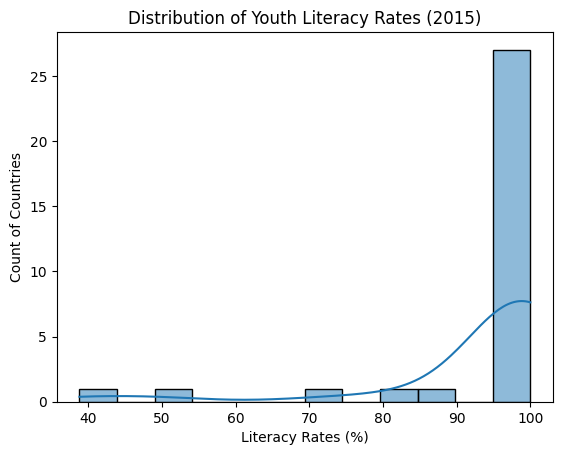

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(literacy_2015, kde=True)
plt.title('Distribution of Youth Literacy Rates (2015)')
plt.xlabel('Literacy Rates (%)')
plt.ylabel('Count of Countries')
plt.show()

The histogram demonstrates that the majority of countries have youth literacy rates very close to 100% indicating that in most of the world, basic literacy levels are significantly high. However, there is a small number of countries with extremely low literacy rates falling behind and showing a long tail towards the lower end of distribution. 

The pattern shows a left skewed distribution where most values are concentrated on a high end with the few performing poorly outliers.  While youth literacy rates are high, there are some falling behind highlighting the continuing educational inequality across certain regions. 

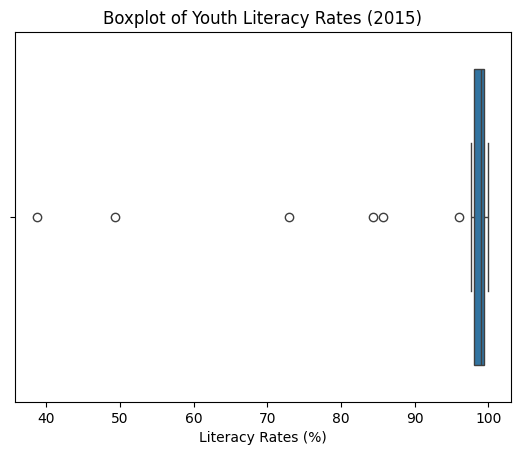

In [17]:
sns.boxplot(x=literacy_2015)
plt.title("Boxplot of Youth Literacy Rates (2015)")
plt.xlabel("Literacy Rates (%)")
plt.show()

The boxplot demonstrates the high youth literacy rates clustered to nearly 100%. The narrow box and short whiskers demonstrate that the majority of countries fall within a small high-performing range. Nevertheless, there were some outliers with some countries with significantly low amounts of literacy rates. This indicates that while global youth literacy rates are extremely high, there are still some major disparities amongst certain regions.  

In [18]:
mean_values = literacy_2015.mean()
median_values = literacy_2015.median()
mode_values = literacy_2015.mode()

mean_values, median_values, mode_values

(np.float64(93.85775781250001),
 np.float64(98.981705),
 0    100.0
 Name: 2015, dtype: float64)

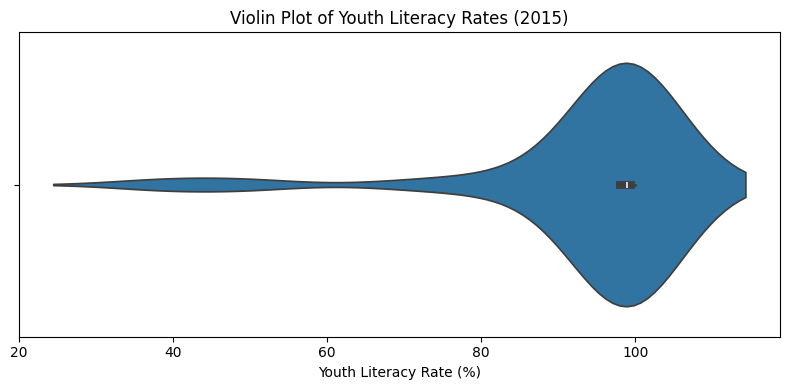

In [19]:
df = pd.read_csv("EdStatsData.csv (2).zip", compression="zip")

literacy = df[df["Indicator Name"] == "Youth literacy rate, population 15-24 years, both sexes (%)"]
literacy_2015 = literacy["2015"].dropna()

plt.figure(figsize=(8, 4))
sns.violinplot(x=literacy_2015)
plt.title("Violin Plot of Youth Literacy Rates (2015)")
plt.xlabel("Youth Literacy Rate (%)")
plt.tight_layout()
plt.show()

The mean literacy rates in 2015 were 93.85%, while the median was significantly higher with 98.98%. The mode is 100% showing that the literacy rates in certain countries is fully literacy. The discrepancy between the mean value and median values demonstrate that there are specific countries with lower literacy rates that are dragging the numbers down. This reinforces the histogram and boxplot that is shown above. 

CONCLUSION - Overall, the majority of countries are at high literacy rates but there are certain regions or countries that are drastically behind showing that while global progress is increasing, there are some educational disparities. This univariate analysis provides a strong foundation for assessing and comparing region levels and income levels.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

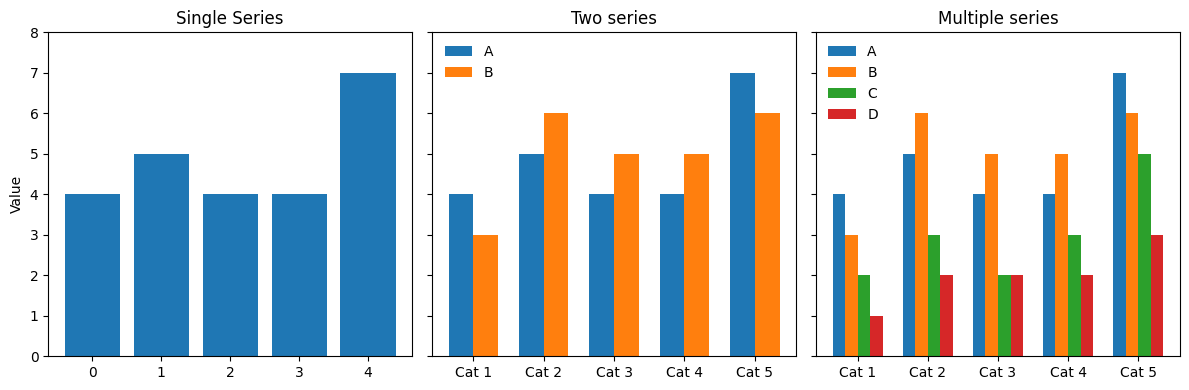

: 

In [ ]:
cats = ['Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']
x = np.arange(len(cats))

single = np.array([4,5,4,4,7])

two_A = np.array([4,5,4,4,7])
two_B = np.array([3,6,5,5,6])

multi_A = np.array([4,5,4,4,7])
multi_B = np.array([3,6,5,5,6])
multi_C = np.array([2,3,2,3,5])
multi_D = np.array([1,2,2,2,3])

fig, axes = plt.subplots(1,3,figsize=(12,4), sharey=True)

# Single Series

axes[0].bar(x, single)
axes[0].set_title('Single Series')
axes[0].set_xticks(x)
axes[0].set_ylim(0,8)
axes[0].set_ylabel("Value")

# Two Series
w = 0.35
axes[1].bar(x - w/2, two_A, width=w, label="A")
axes[1].bar(x + w/2, two_B, width=w, label="B")
axes[1].set_title("Two series")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_ylim(0, 8)
axes[1].legend(frameon=False, loc="upper left")

# Three Series 
w2 = 0.18
axes[2].bar(x - 1.5*w2, multi_A, width=w2, label="A")
axes[2].bar(x - 0.5*w2, multi_B, width=w2, label="B")
axes[2].bar(x + 0.5*w2, multi_C, width=w2, label="C")
axes[2].bar(x + 1.5*w2, multi_D, width=w2, label="D")
axes[2].set_title("Multiple series")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cats)
axes[2].set_ylim(0, 8)
axes[2].legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()


I recreated the figure from page 54 of Storytelling with Data to illustrate how bar charts change as additional data series are introduced. With a single series, differences between categories are clear and easy to interpret. However, as more series are added, it becomes increasingly difficult to focus and accurately compare values across categories. This demonstrates the importance of intentional design choices, such as limiting the number of series and using clear, distinguishable formatting to improve interpretability.